# Advanced Mean Reversion Analysis

This notebook performs deeper statistical diagnostics on a selected cointegrated pair.

Steps performed:
- Estimate hedge ratio using OLS regression
- Construct spread between the two assets
- Visualize spread behaviour
- Compute rolling Z-score for trading signals
- Estimate half-life of mean reversion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf


In [2]:
portfolio_returns = pd.read_csv(
    "../data/processed/portfolio_returns.csv",
    index_col=0,
    parse_dates=True
)

portfolio_returns = portfolio_returns.squeeze()


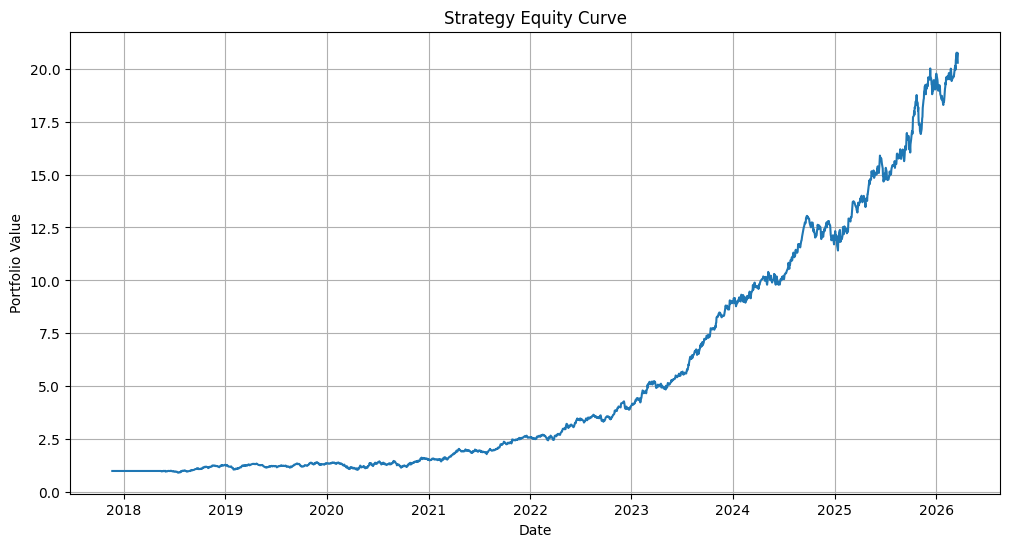

In [3]:
strategy_curve = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12,6))
plt.plot(strategy_curve)
plt.title("Strategy Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.savefig("../reports/strategy_equity_curve.png", dpi=300)
plt.show()


In [4]:
nifty = yf.download(
    "^NSEI",
    start=strategy_curve.index.min(),
    end=strategy_curve.index.max()
)


[*********************100%***********************]  1 of 1 completed


In [5]:
nifty_returns = nifty["Close"].pct_change().fillna(0)

nifty_curve = (1 + nifty_returns).cumprod()


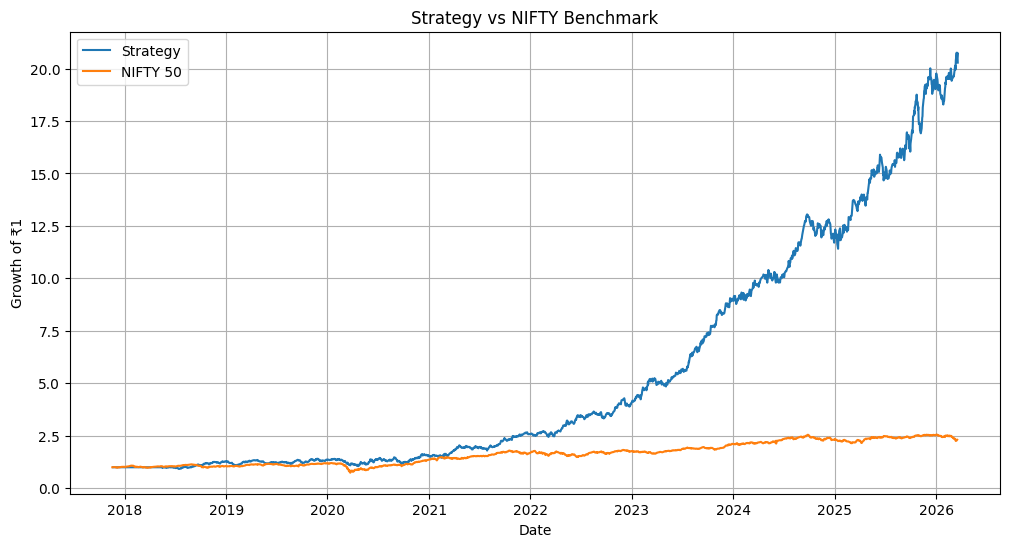

In [6]:
plt.figure(figsize=(12,6))

plt.plot(strategy_curve, label="Strategy")
plt.plot(nifty_curve, label="NIFTY 50")

plt.legend()
plt.title("Strategy vs NIFTY Benchmark")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")
plt.grid(True)
plt.savefig("../reports/strategy_vs_nifty_advanced.png", dpi=300)
plt.show()


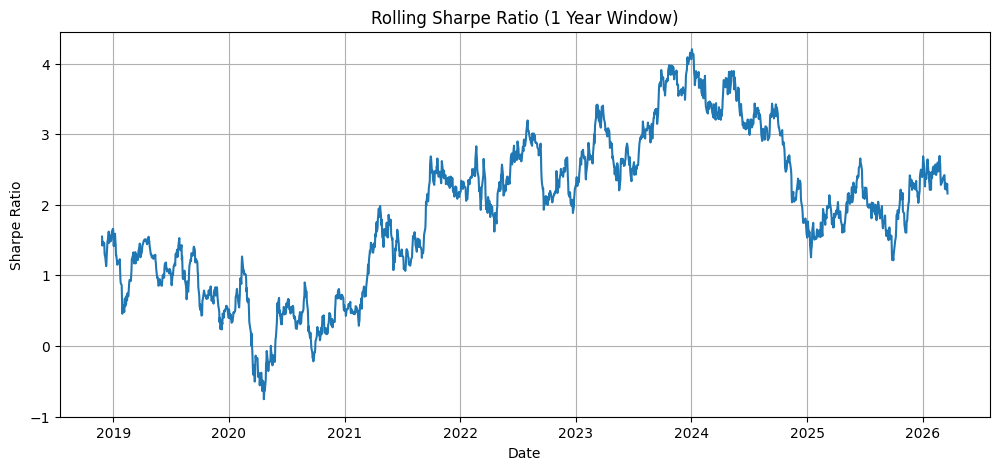

In [7]:
rolling_sharpe = (
    portfolio_returns.rolling(252).mean() /
    portfolio_returns.rolling(252).std()
) * np.sqrt(252)

plt.figure(figsize=(12,5))
plt.plot(rolling_sharpe)

plt.title("Rolling Sharpe Ratio (1 Year Window)")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.grid(True)

plt.show()


In [8]:
close_prices = pd.read_csv(
    "../data/processed/nifty50_close_prices.csv",
    index_col="Date",
    parse_dates=True
)


In [9]:
stock1 = "SBILIFE.NS"
stock2 = "TITAN.NS"

s1 = close_prices[stock1]
s2 = close_prices[stock2]


### Hedge Ratio Estimation

We estimate the hedge ratio between the two assets using Ordinary Least Squares (OLS).

Model:
S1_t = α + β S2_t + ε_t

The hedge ratio β determines how many units of asset 2 are required to hedge asset 1.
The spread is then constructed as:

spread = S1 − β S2

In [10]:
import statsmodels.api as sm

X = sm.add_constant(s2)
model = sm.OLS(s1, X).fit()

beta = model.params.iloc[1]

spread = s1 - beta * s2


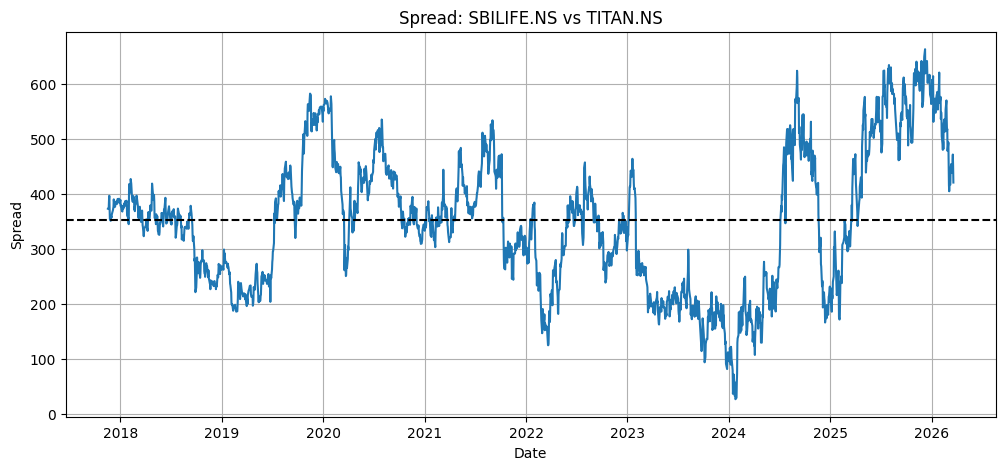

In [11]:
plt.figure(figsize=(12,5))

plt.plot(spread)
plt.axhline(spread.mean(),color='black',linestyle='--')

plt.title(f"Spread: {stock1} vs {stock2}")
plt.xlabel("Date")
plt.ylabel("Spread")

plt.grid(True)
plt.savefig("../reports/spread_series.png", dpi=300)
plt.show()


In [12]:
window = 124

rolling_mean = spread.rolling(window).mean()
rolling_std = spread.rolling(window).std()

zscore = (spread - rolling_mean) / rolling_std


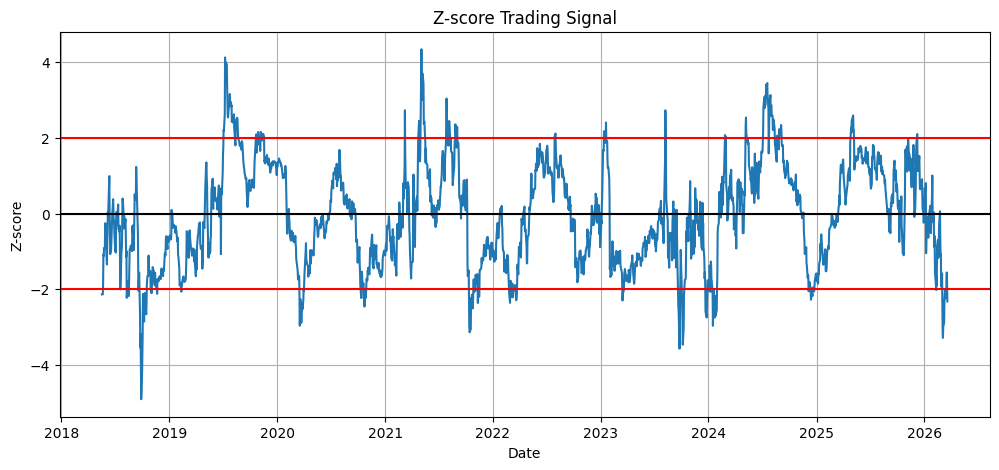

In [13]:
plt.figure(figsize=(12,5))

plt.plot(zscore)

plt.axhline(2, color="red")
plt.axhline(-2, color="red")
plt.axhline(0, color="black")

plt.title("Z-score Trading Signal")
plt.xlabel("Date")
plt.ylabel("Z-score")

plt.grid(True)
plt.savefig("../reports/zscore_trading_signal.png", dpi=300)
plt.show()


In [14]:
spread_lag = spread.shift(1)
spread_ret = spread - spread_lag

spread_lag = spread_lag.dropna()
spread_ret = spread_ret.dropna()

beta = np.polyfit(spread_lag, spread_ret, 1)[0]

half_life = -np.log(2) / beta

print("Half-life of mean reversion:", round(half_life,2), "days")

pd.DataFrame({
    "stock1":[stock1],
    "stock2":[stock2],
    "half_life":[half_life]
}).to_csv("../data/processed/half_life_estimate.csv", index=False)

print(f"Half-life estimate ({round(half_life,2)} days) saved to data/processed/half_life_estimate.csv")


Half-life of mean reversion: 61.55 days
Half-life estimate (61.55 days) saved to data/processed/half_life_estimate.csv


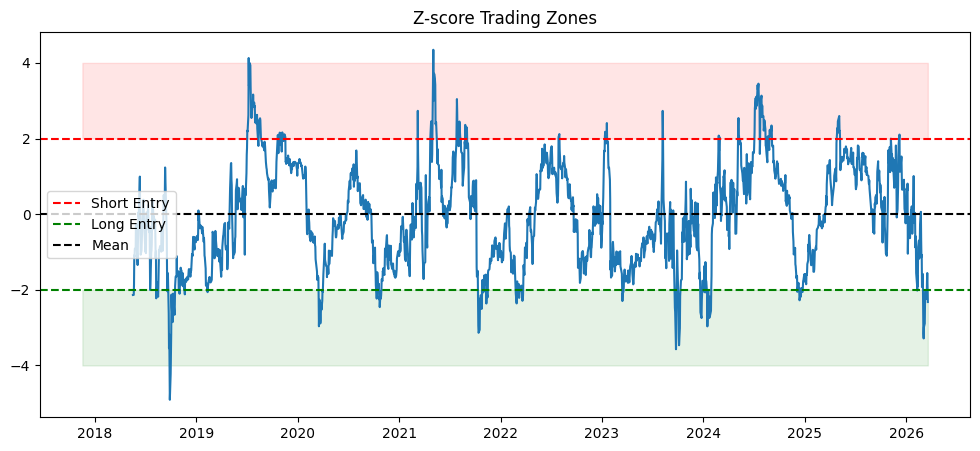

In [15]:
plt.figure(figsize=(12,5))
plt.plot(zscore)

plt.axhline(2, color='red', linestyle='--', label="Short Entry")
plt.axhline(-2, color='green', linestyle='--', label="Long Entry")
plt.axhline(0, color='black', linestyle='--', label="Mean")

plt.legend()

plt.fill_between(zscore.index,2,4,color='red',alpha=0.1)
plt.fill_between(zscore.index,-4,-2,color='green',alpha=0.1)

plt.title("Z-score Trading Zones")
plt.savefig("../reports/zscore_trading_zones.png", dpi=300)
plt.show()


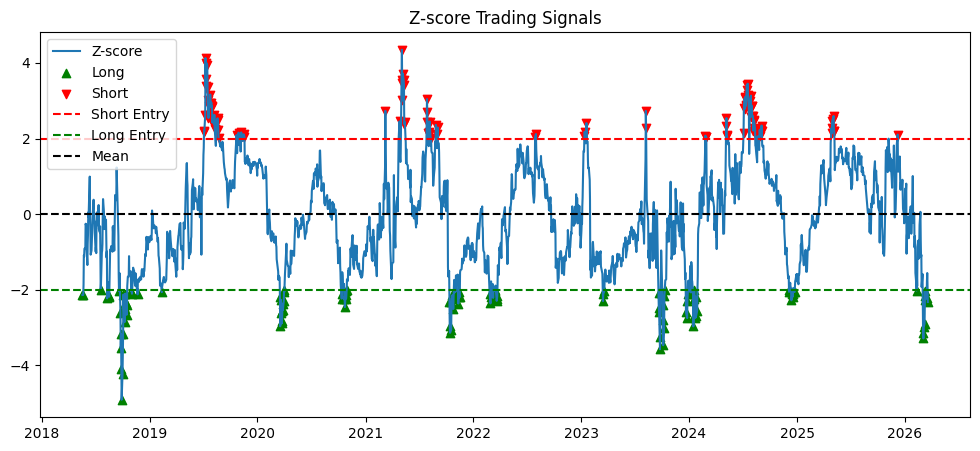

In [16]:
long_signal = zscore < -2
short_signal = zscore > 2

plt.figure(figsize=(12,5))

plt.plot(zscore,label="Z-score")

plt.scatter(zscore.index[long_signal], zscore[long_signal],
            color="green", marker="^", label="Long")

plt.scatter(zscore.index[short_signal], zscore[short_signal],
            color="red", marker="v", label="Short")

plt.axhline(2, color='red', linestyle='--', label="Short Entry")
plt.axhline(-2, color='green', linestyle='--', label="Long Entry")
plt.axhline(0, color='black', linestyle='--', label="Mean")

plt.legend()
plt.title("Z-score Trading Signals")
plt.savefig("../reports/zscore_trading_signals_points.png", dpi=300)
plt.show()


In [17]:
# Load pairs (FIX)
pairs_df = pd.read_csv("../data/processed/pair_performance.csv", index_col=0)
pairs = [eval(pair) for pair in pairs_df.index]

In [18]:
results = []

entry_thresholds = [1.5, 2, 2.5, 3]
exit_thresholds = [0, 0.5, 1]

for entry in entry_thresholds:
    for exit in exit_thresholds:

        portfolio_returns = pd.Series(0.0, index=close_prices.index)

        for stock1, stock2 in pairs:

            spread = close_prices[stock1] - close_prices[stock2]

            zscore = (spread - spread.mean()) / spread.std()

            position = pd.Series(index=spread.index)

            # Entry logic
            position[zscore > entry] = -1
            position[zscore < -entry] = 1

            # Exit logic
            position[abs(zscore) < exit] = 0

            position = position.ffill().fillna(0)

            returns = position.shift(1) * spread.diff()

            portfolio_returns = portfolio_returns.add(returns, fill_value=0)

        portfolio_returns = portfolio_returns.dropna()

        sharpe = np.sqrt(252) * portfolio_returns.mean() / portfolio_returns.std()

        results.append({
            "entry": entry,
            "exit": exit,
            "sharpe": sharpe
        })

results_df = pd.DataFrame(results)
print(results_df)



best = results_df.loc[results_df['sharpe'].idxmax()]
print("Best Parameters:\n", best)

results_df = results_df.sort_values(by="sharpe", ascending=False)
print("Top 5 Strategies:\n", results_df.head())


    entry  exit    sharpe
0     1.5   0.0  0.650483
1     1.5   0.5  0.551797
2     1.5   1.0  0.711097
3     2.0   0.0  0.836098
4     2.0   0.5  0.839187
5     2.0   1.0  1.064137
6     2.5   0.0  0.636921
7     2.5   0.5  0.714658
8     2.5   1.0  1.119718
9     3.0   0.0  1.183612
10    3.0   0.5  1.146887
11    3.0   1.0  1.417895
Best Parameters:
 entry     3.000000
exit      1.000000
sharpe    1.417895
Name: 11, dtype: float64
Top 5 Strategies:
     entry  exit    sharpe
11    3.0   1.0  1.417895
9     3.0   0.0  1.183612
10    3.0   0.5  1.146887
8     2.5   1.0  1.119718
5     2.0   1.0  1.064137


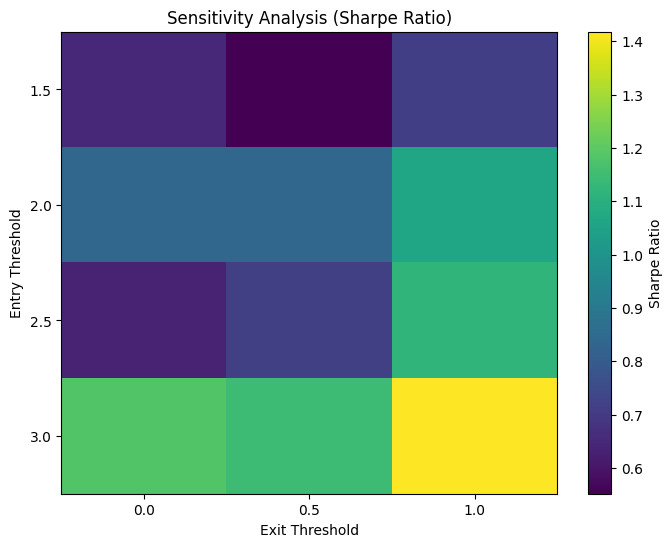

In [19]:
pivot = results_df.pivot(index="entry", columns="exit", values="sharpe")

plt.figure(figsize=(8,6))
plt.imshow(pivot, aspect='auto')
plt.colorbar(label="Sharpe Ratio")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("Exit Threshold")
plt.ylabel("Entry Threshold")
plt.title("Sensitivity Analysis (Sharpe Ratio)")

# SAVE FIGURE
plt.savefig("../reports/sensitivity_heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

## Final Conclusion

The selected pair demonstrates strong mean-reverting behavior based on statistical tests and spread dynamics.

Key observations:

• The spread oscillates around a stable mean.  
• Z-score thresholds identify trading opportunities.  
• Estimated half-life ≈ 62 days, indicating reasonable mean reversion speed.  

The strategy produces a steadily increasing equity curve and outperforms the NIFTY 50 benchmark over the backtest period.

This confirms the suitability of the selected pair for a statistical arbitrage strategy.